In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

configuration + loading dataset

In [2]:
RANDOM_STATE = 42

In [3]:
DATA_PATH = '../data/combined_dataset.csv'

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")
df.head()

Dataset Shape : (85008, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank
0,ce39a363-2cc3-47bc-b08f-eed5aaf1bd5a,Frandika Bule,https://play-lh.googleusercontent.com/a/ACg8oc...,Versi 4.5.5 tidak bisa dibuka,1,0,4.5.5,2025-01-02 17:09:03,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2025-01-02 18:29:10,4.5.5,BCAMOBILE_REVIEWS
1,78e922fb-9073-493b-957e-c4a05a0bf671,muhammad farhan,https://play-lh.googleusercontent.com/a-/ALV-U...,Kenapa tiba² force close di S10+ Setelah di up...,2,0,4.5.0,2024-10-23 00:07:27,Silakan mencoba secara berkala untuk menonakti...,2024-10-23 18:00:22,4.5.0,BCAMOBILE_REVIEWS
2,58d354f8-f49e-4323-adf9-13e7248bebd5,Wildan Herdiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,BANK KONYOL,1,0,NaN,2023-11-07 17:58:47,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2023-11-07 18:55:47,NaN,BCAMOBILE_REVIEWS
3,39b5b0dd-4b4e-4705-9ca5-1a2744f7bec0,Imam Anjasmara,https://play-lh.googleusercontent.com/a-/ALV-U...,Dari tanggal 14 kemarin apk bca Mobile nya gk ...,1,4,4.7.4,2025-10-16 21:24:49,Sangat disayangkan atas kendala yang terjadi. ...,2025-10-16 22:06:33,4.7.4,BCAMOBILE_REVIEWS
4,dd53feb8-f857-462d-8d7b-3fb518bfd5c0,Deri Kancil,https://play-lh.googleusercontent.com/a-/ALV-U...,Kenapa sih kaya tiap bulan itu sering banget g...,1,0,NaN,2024-04-25 10:53:16,Mohon maaf atas ketidaknyamanannya. Ulasan Bap...,2024-04-25 11:45:19,NaN,BCAMOBILE_REVIEWS


Dataset Overview

In [4]:
print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names")
display(pd.DataFrame(df.columns, columns=["Columns"]))

print("\nData Types")
display(df.dtypes.to_frame("Data Type"))

display(df.head())

Number of Rows    : 85,008
Number of Columns : 12

Column Names


,Columns
0,reviewId
1,userName
2,userImage
3,content
4,score
5,thumbsUpCount
6,reviewCreatedVersion
7,at
8,replyContent
9,repliedAt



Data Types


,Data Type
reviewId,object
userName,object
userImage,object
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,object
replyContent,object
repliedAt,object


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank
0,ce39a363-2cc3-47bc-b08f-eed5aaf1bd5a,Frandika Bule,https://play-lh.googleusercontent.com/a/ACg8oc...,Versi 4.5.5 tidak bisa dibuka,1,0,4.5.5,2025-01-02 17:09:03,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2025-01-02 18:29:10,4.5.5,BCAMOBILE_REVIEWS
1,78e922fb-9073-493b-957e-c4a05a0bf671,muhammad farhan,https://play-lh.googleusercontent.com/a-/ALV-U...,Kenapa tiba² force close di S10+ Setelah di up...,2,0,4.5.0,2024-10-23 00:07:27,Silakan mencoba secara berkala untuk menonakti...,2024-10-23 18:00:22,4.5.0,BCAMOBILE_REVIEWS
2,58d354f8-f49e-4323-adf9-13e7248bebd5,Wildan Herdiansyah,https://play-lh.googleusercontent.com/a-/ALV-U...,BANK KONYOL,1,0,NaN,2023-11-07 17:58:47,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, unt...",2023-11-07 18:55:47,NaN,BCAMOBILE_REVIEWS
3,39b5b0dd-4b4e-4705-9ca5-1a2744f7bec0,Imam Anjasmara,https://play-lh.googleusercontent.com/a-/ALV-U...,Dari tanggal 14 kemarin apk bca Mobile nya gk ...,1,4,4.7.4,2025-10-16 21:24:49,Sangat disayangkan atas kendala yang terjadi. ...,2025-10-16 22:06:33,4.7.4,BCAMOBILE_REVIEWS
4,dd53feb8-f857-462d-8d7b-3fb518bfd5c0,Deri Kancil,https://play-lh.googleusercontent.com/a-/ALV-U...,Kenapa sih kaya tiap bulan itu sering banget g...,1,0,NaN,2024-04-25 10:53:16,Mohon maaf atas ketidaknyamanannya. Ulasan Bap...,2024-04-25 11:45:19,NaN,BCAMOBILE_REVIEWS


checking missing values

In [5]:
missing = pd.DataFrame({
  "Missing Count": df.isnull().sum(),
  "Missing (%)": (
      df.isnull().mean() * 100
  ).round(2)
})

missing = missing.sort_values(
  by="Missing Count",
  ascending=False
)

display(missing)

,Missing Count,Missing (%)
appVersion,17527,20.62
reviewCreatedVersion,17527,20.62
repliedAt,653,0.77
replyContent,653,0.77
content,0,0.00
userImage,0,0.00
userName,0,0.00
reviewId,0,0.00
at,0,0.00
thumbsUpCount,0,0.00


checking duplicates

In [6]:
duplicate_summary = pd.DataFrame({
  "Column": df.columns,
  "Duplicate Values": [df[col].duplicated().sum() for col in df.columns],
  "Unique Values": [df[col].nunique() for col in df.columns]
})

duplicate_summary

,Column,Duplicate Values,Unique Values
0,reviewId,0,85008
1,userName,3608,81400
2,userImage,564,84444
3,content,2886,82122
4,score,85005,3
5,thumbsUpCount,84770,238
6,reviewCreatedVersion,84768,239
7,at,226,84782
8,replyContent,34622,50385
9,repliedAt,1038,83969


In [7]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows:,}")

Duplicate Rows: 0


In [8]:
duplicate_content = df[df.duplicated(subset=["content"], keep=False)].sort_values("content")

duplicate_content

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,bank
14070,133a8521-961b-4eae-b421-aa2e017ab3ca,linda laksanawati,https://play-lh.googleusercontent.com/a-/ALV-U...,0 privasi,1,0,4.6.6,2025-08-14 19:05:02,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2025-08-14 19:57:26,4.6.6,BCAMOBILE_REVIEWS
14538,6c518fdf-817d-4e2e-ae57-89d70c3d1bd5,Nia Wati,https://play-lh.googleusercontent.com/a/ACg8oc...,0 privasi,1,0,NaN,2025-08-14 20:39:50,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2025-08-14 22:47:49,NaN,BCAMOBILE_REVIEWS
8635,e603fdb7-3368-4cc0-be9f-1a113d1d4e7e,Rida Riwayati,https://play-lh.googleusercontent.com/a/ACg8oc...,0 privasi,1,0,NaN,2025-08-15 06:18:07,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2025-08-15 18:06:10,NaN,BCAMOBILE_REVIEWS
16331,25227645-4941-4974-a304-15a86f20b237,Sendi Prasijo,https://play-lh.googleusercontent.com/a/ACg8oc...,0 privasi,1,0,NaN,2025-08-15 09:44:16,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2025-08-15 17:55:19,NaN,BCAMOBILE_REVIEWS
13615,54a94cc7-af51-4ef2-9c23-d0549526df71,ANDELIAN HUMAEROH 05,https://play-lh.googleusercontent.com/a-/ALV-U...,0 privasi,1,0,4.6.8,2025-08-15 00:40:32,-,2025-08-19 21:07:47,4.6.8,BCAMOBILE_REVIEWS
...,...,...,...,...,...,...,...,...,...,...,...,...
3496,e9dccb1a-ba42-45b1-80e7-04bcb49ee568,Yanuar Nowo,https://play-lh.googleusercontent.com/a-/ALV-U...,😐,2,0,4.1.2,2023-09-15 00:47:15,Terima kasih atas ulasannya. Semoga aplikasi B...,2023-09-15 01:21:55,4.1.2,BCAMOBILE_REVIEWS
81503,5f5adae4-74ec-4fb8-87ca-fcf57e3786f6,Hardian Syafitra,https://play-lh.googleusercontent.com/a-/ALV-U...,😮‍💨,3,0,1.4.4,2025-12-05 13:35:46,"Halo Kak Hardian Syafitra, maaf sekali ya untu...",2025-12-07 08:45:07,1.4.4,WONDR_BNI_REVIEWS
84008,f4cbbb7e-3611-4bc4-99ae-c98b02d17183,Imron Wahyudi,https://play-lh.googleusercontent.com/a/ACg8oc...,😮‍💨,1,0,1.3.1,2025-04-23 09:52:54,"Hai Kak Imron Wahyudi, mohon maaf atas ketidak...",2025-04-23 10:19:54,1.3.1,WONDR_BNI_REVIEWS
54117,9c548226-867e-4202-800f-eb7f42d2f4d8,Bella Solpiana,https://play-lh.googleusercontent.com/a-/ALV-U...,🙏🙏🙏,3,0,2.1.0,2024-12-13 17:12:08,"Halo Sahabat @Bella Solpiana, terima kasih ata...",2024-12-14 13:04:36,2.1.0,LIVIN_MANDIRI_REVIEWS


In [9]:
# OUTPUT_DIR = Path("../data")

# duplicate_content.to_csv(
#     OUTPUT_DIR / "duplicate_content.csv",
#     index=False
# )

Rating Distribution

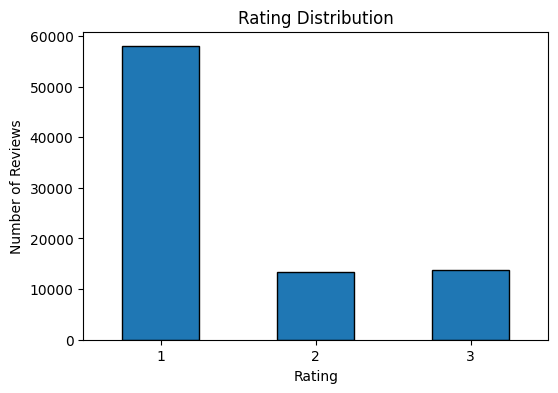

In [11]:
plt.figure(figsize=(6,4))

rating_dist.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

Review Length

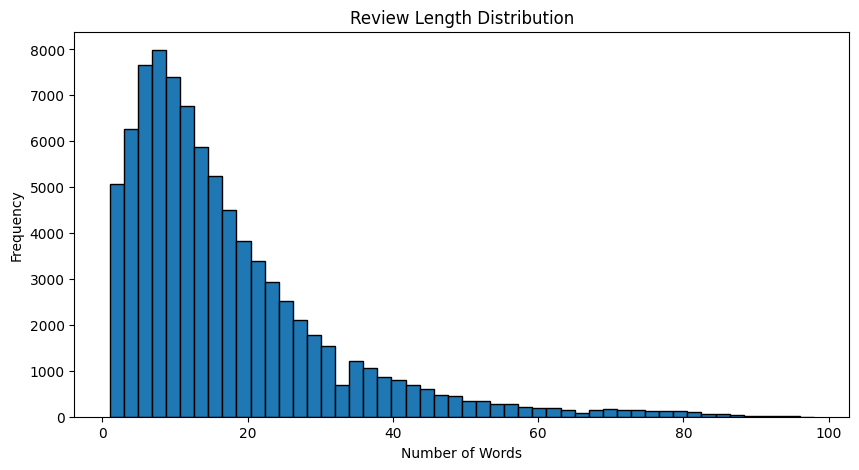

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50,
    edgecolor="black"
)

plt.title("Review Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

Summary

In [15]:
summary = pd.DataFrame({

    "Metric":[

        "Total Reviews",

        "Average Review Length",

        "Median Review Length",

        "Shortest Review",

        "Longest Review"

    ],

    "Value":[

        len(df),

        round(df.review_length.mean(),2),

        round(df.review_length.median(),2),

        df.review_length.min(),

        df.review_length.max()

    ]

})

summary

,Metric,Value
0,Total Reviews,85008.00
1,Average Review Length,16.94
2,Median Review Length,13.00
3,Shortest Review,1.00
4,Longest Review,98.00
